<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/Hierarchical_Clustering_in_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hierarchical Clustering is an unsupervised learning technique that groups data into a hierarchy of clusters based on similarity. It builds a tree‑like structure (dendrogram) that helps visualize relationships and decide the optimal number of clusters.

Does not require pre‑selecting the number of clusters.
Uses agglomerative or divisive approaches.
Commonly applied in data exploration and pattern discovery.
It is commonly used in pattern recognition, customer segmentation and image grouping.Imagine we have four fruits with different weights: an apple (100g), a banana (120g), a cherry (50g) and a grape (30g). Hierarchical clustering starts by treating each fruit as its own group.

Start with each fruit as its own cluster.
Merge the closest items: grape (30g) and cherry (50g) are grouped first.
Next, apple (100g) and banana (120g) are grouped.
Finally, these two clusters merge into one.
Finally all the fruits are merged into one large group, showing how hierarchical clustering progressively combines the most similar data points.

Dendrogram
A dendrogram is like a family tree for clusters. It shows how individual data points or groups of data merge together. The bottom shows each data point as its own group and as we move up, similar groups are combined.

The lower the merge point, the more similar the groups are. It helps us see how things are grouped step by step.

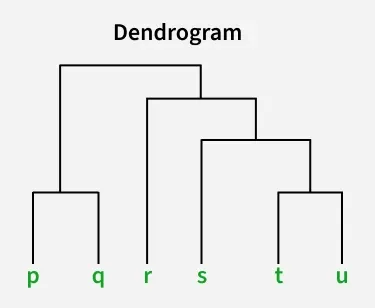

At the bottom of the dendrogram the points P, Q, R, S and T are all separate.
As we move up, the closest points are merged into a single group.
The lines connecting the points show how they are progressively merged based on similarity.
The height at which they are connected shows how similar the points are to each other; the shorter the line the more similar they are
Types of Hierarchical Clustering
Now we understand the basics of hierarchical clustering. There are two main types of hierarchical clustering.

Agglomerative Clustering
Divisive clustering
1. Hierarchical Agglomerative Clustering
It is also known as the bottom-up approach or hierarchical agglomerative clustering (HAC). Bottom-up algorithms treat each data as a singleton cluster at the outset and then successively agglomerate pairs of clusters until all clusters have been merged into a single cluster that contains all data.

Workflow for Hierarchical Agglomerative clustering
Start with individual points: Each data point is its own cluster. For example if we have 5 data points we start with 5 clusters each containing just one data point.
Calculate distances between clusters: Calculate the distance between every pair of clusters. Initially since each cluster has one point this is the distance between the two data points.
Merge the closest clusters: Identify the two clusters with the smallest distance and merge them into a single cluster.
Update distance matrix: After merging we now have one less cluster. Recalculate the distances between the new cluster and the remaining clusters.
Repeat steps 3 and 4: Keep merging the closest clusters and updating the distance matrix until we have only one cluster left.
Create a dendrogram: As the process continues we can visualize the merging of clusters using a tree-like diagram called a dendrogram. It shows the hierarchy of how clusters are merged.
Implementation
Let's see the implementation of Agglomerative Clustering,

Start with each data point as its own cluster.
Compute distances between all clusters.
Merge the two closest clusters based on a linkage method.
Update the distances to reflect the new cluster.
Repeat merging until the desired number of clusters or one cluster remains.
The dendrogram visualizes these merges as a tree, showing cluster relationships and distances.

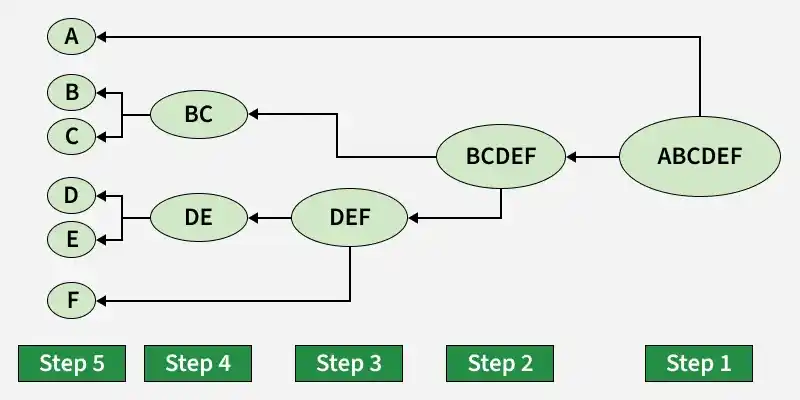

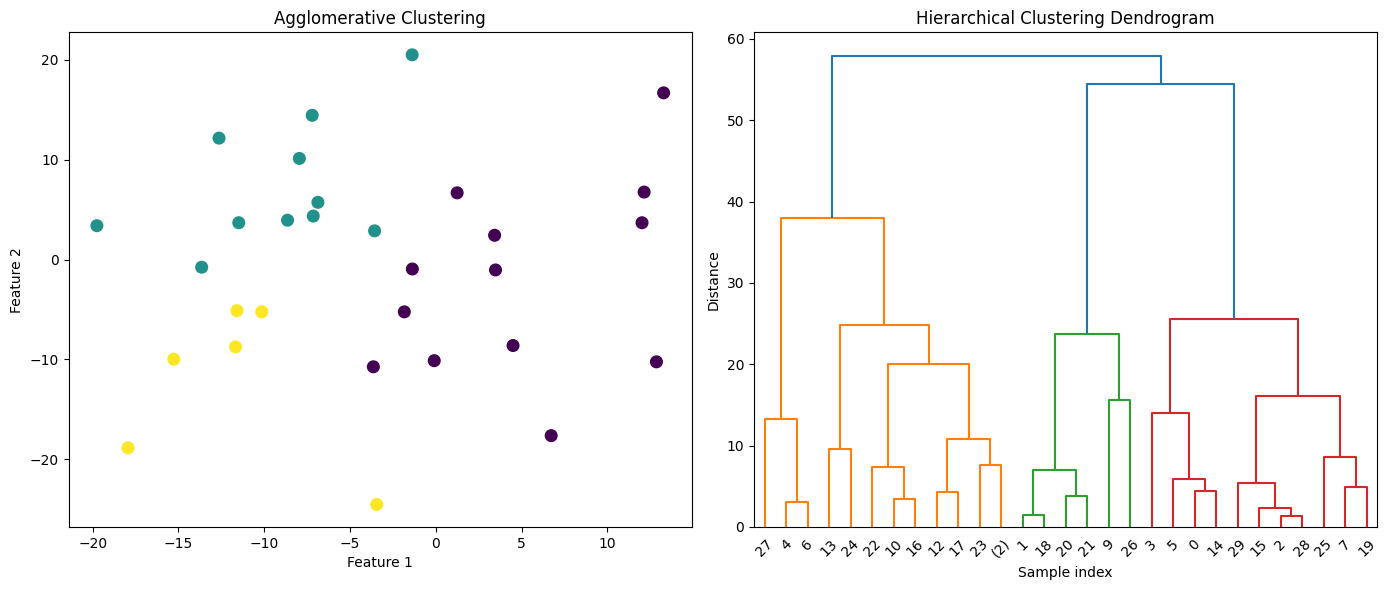

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=30, centers=3, cluster_std=10, random_state=42)

clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()